<a href="https://colab.research.google.com/github/mpatel5/Midterm-Project-Part-1---Linear-Regression/blob/main/Patel_Midterm_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the required libraries

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load and preview data





In [140]:
# Load dataset from a github (medicalcost.csv)
df = pd.read_csv("https://raw.githubusercontent.com/raquelmangual/Midterm-datasets/main/medicalcost.csv")

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- DataFrame Info ---")
df.info()

print("\n--- Summary Statistics (Numeric) ---")
print(df.describe())

print("\n--- Data Types (Before Cleaning) ---")
print(df.dtypes)

print("\n--- Missing Values Per Column (Before Cleaning) ---")
print(df.isnull().sum())


--- First 5 Rows ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Summary Statistics (Numeric) ---
            

# Visualize distribution of the data

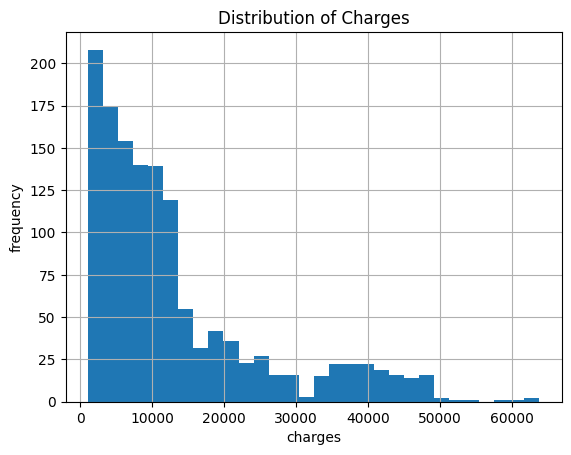

In [141]:
plt.figure()
df["charges"].hist(bins=30)
plt.title("Distribution of Charges")
plt.xlabel("charges")
plt.ylabel("frequency")
plt.show()

# Data Cleaning and Preprocessing

In [155]:
# Check duplicates
duplicate_count = df.duplicated().sum()
print("\n--- Duplicate Rows (Before Cleaning) ---")
print(duplicate_count)

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values:
# - Numeric columns: fill with median (because it is not strongly affected by extreme values)
# - Categorical columns: fill with mode (most common value)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# Convert smoker to numeric (yes=1, no=0) for regression
# This is done because regression models need numeric inputs
if "smoker" in df.columns and df["smoker"].dtype == "object":
    df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})

# Confirm cleaning
print("\n--- Missing Values Per Column (After Cleaning) ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows (After Cleaning) ---")
print(df.duplicated().sum())

print("\n--- Summary Statistics (After Cleaning) ---")
print(df.describe())

print("\n--- Data Types (After Cleaning) ---")
print(df.dtypes)

print("\n--- Final Data Shape ---")
print(df.shape)


--- Duplicate Rows (Before Cleaning) ---
0

--- Missing Values Per Column (After Cleaning) ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Duplicate Rows (After Cleaning) ---
0

--- Summary Statistics (After Cleaning) ---
               age          bmi     children       smoker       charges
count  1337.000000  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737     0.204936  13279.121487
std      14.044333     6.100468     1.205571     0.403806  12110.359656
min      18.000000    15.960000     0.000000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000     0.000000   9386.161300
75%      51.000000    34.700000     2.000000     0.000000  16657.717450
max      64.000000    53.130000     5.000000     1.000000  63770.428010

--- Data Types (After Cleaning) ---
age           int64


# Compare single predictors (one at a time)

In [143]:
target = "charges"
predictors_to_test = ["age", "bmi", "smoker"]

print("\n--- Comparing Single Predictors (Linear Regression) ---")

results = {}

for predictor in predictors_to_test:
    # Skip predictors not found (just in case)
    if predictor not in df.columns:
        print(f"{predictor} not found in dataset columns. Skipping.")
        continue

    # Define X (feature) and y (target)
    X = df[[predictor]]
    y = df[target]

    # Train/test split (70% train, 30% test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    # Train model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred = model.predict(X_test)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[predictor] = {"rmse": rmse, "r2": r2}

    print(f"{predictor} → RMSE: {rmse:,.0f} | R²: {r2:.4f} ({r2*100:.2f}%)")


--- Comparing Single Predictors (Linear Regression) ---
age → RMSE: 12,431 | R²: 0.0970 (9.70%)
bmi → RMSE: 12,710 | R²: 0.0560 (5.60%)
smoker → RMSE: 7,807 | R²: 0.6438 (64.38%)


# Select best predictor and build final linear regression model

In [144]:
# Predictor choice:
# I chose "smoker" because it showed the strongest relationship with charges in the single-predictor comparison
# (highest R² / lowest RMSE), and smoking status is known to significantly impact medical costs.

best_predictor = "smoker"

print(f"\n--- Building Final Model Using: {best_predictor} ---")

X = df[[best_predictor]]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)






--- Building Final Model Using: smoker ---


LinearRegression()

# Model Coefficients

In [156]:
# Output the coefficients for the model
print("\n--- Model Coefficients ---")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Coefficient for {best_predictor}: {model.coef_[0]:.2f}")


--- Model Coefficients ---
Intercept: 8407.91
Coefficient for smoker: 22301.00


# Make the predictions

In [146]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model

In [147]:
# Model evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Final Model Performance ---")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.4f}")
print(f"Accuracy (%): {r2*100:.2f}%")

print(
    f"The linear regression model using {best_predictor} as the predictor "
    f"produced an R² value of {r2:.4f}, meaning that approximately "
    f"{r2*100:.2f}% of the variance in medical charges is explained by "
    f"{best_predictor}. This indicates that {best_predictor} is a stronger "
    f"predictor compared to the others tested."
)


--- Final Model Performance ---
RMSE: 7807.046
R²: 0.6438
Accuracy (%): 64.38%
The linear regression model using smoker as the predictor produced an R² value of 0.6438, meaning that approximately 64.38% of the variance in medical charges is explained by smoker. This indicates that smoker is a stronger predictor compared to the others tested.


# Visualize the model

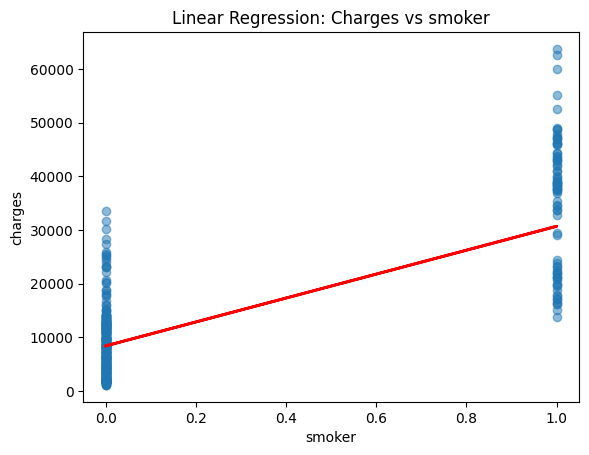

In [154]:
plt.figure()

# Scatter plot of actual data
plt.scatter(X_test, y_test, alpha=0.5)

# Plot regression line in red
plt.plot(X_test, y_pred, color='red', linewidth=2)

plt.title(f"Linear Regression: Charges vs {best_predictor}")
plt.xlabel(best_predictor)
plt.ylabel("charges")
plt.show()